In [1]:
!git clone https://github.com/uzbtrust/Uzbek-Operator-NER-From-Scratch.git
%cd Uzbek-Operator-NER-From-Scratch
!pip install -q seqeval pyyaml

Cloning into 'Uzbek-Operator-NER-From-Scratch'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 53 (delta 16), reused 46 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 26.54 KiB | 1.40 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/kaggle/working/Uzbek-Operator-NER-From-Scratch
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import os
import sys
import time
import json
import yaml
from pathlib import Path

import torch
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, ConcatDataset
from torch.cuda.amp import GradScaler, autocast

sys.path.insert(0, ".")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
    print(f"  Total GPUs: {torch.cuda.device_count()}")

Device: cuda
  GPU 0: Tesla T4
  GPU 1: Tesla T4
  Total GPUs: 2


In [3]:
from data.download_datasets import download_conll, download_wikiann

RAW_DIR = "data/raw"

download_conll(RAW_DIR)
download_wikiann("en", RAW_DIR)
download_wikiann("ru", RAW_DIR)

print("Datasets ready.")

2026-04-06 04:14:29,482 [INFO] Downloading CoNLL-2003 (parquet)...
2026-04-06 04:14:29,647 [INFO] HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/parquet/parquet.py "HTTP/1.1 404 Not Found"
2026-04-06 04:14:29,772 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/conll2003/revision/refs%2Fconvert%2Fparquet "HTTP/1.1 307 Temporary Redirect"
2026-04-06 04:14:29,834 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/eriktks/conll2003/revision/refs%2Fconvert%2Fparquet "HTTP/1.1 200 OK"
2026-04-06 04:14:29,895 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/conll2003/tree/refs%2Fconvert%2Fparquet/conll2003%2Ftrain?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-04-06 04:14:29,973 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/eriktks/conll2003/tree/refs%2Fconvert%2Fparquet/conll2003%2Ftrain?recursive=false&expand=false "HTTP/1.1 200 OK"
2026-04-06 04:14:30,037 [INFO] HTTP Request: GET h

conll2003/train/0000.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

2026-04-06 04:14:32,084 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/conll2003/resolve/refs%2Fconvert%2Fparquet/conll2003/validation/0000.parquet "HTTP/1.1 307 Temporary Redirect"
2026-04-06 04:14:32,146 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/eriktks/conll2003/resolve/refs%2Fconvert%2Fparquet/conll2003/validation/0000.parquet "HTTP/1.1 307 Temporary Redirect"
2026-04-06 04:14:32,163 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/eriktks/conll2003/ce85b39f9dd99f552d0739d456814e95fb6a39b0/conll2003%2Fvalidation%2F0000.parquet "HTTP/1.1 200 OK"
2026-04-06 04:14:32,180 [INFO] HTTP Request: GET https://huggingface.co/api/resolve-cache/datasets/eriktks/conll2003/ce85b39f9dd99f552d0739d456814e95fb6a39b0/conll2003%2Fvalidation%2F0000.parquet "HTTP/1.1 200 OK"


0000.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

2026-04-06 04:14:32,284 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/conll2003/resolve/refs%2Fconvert%2Fparquet/conll2003/test/0000.parquet "HTTP/1.1 307 Temporary Redirect"
2026-04-06 04:14:32,345 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/eriktks/conll2003/resolve/refs%2Fconvert%2Fparquet/conll2003/test/0000.parquet "HTTP/1.1 307 Temporary Redirect"
2026-04-06 04:14:32,363 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/eriktks/conll2003/ce85b39f9dd99f552d0739d456814e95fb6a39b0/conll2003%2Ftest%2F0000.parquet "HTTP/1.1 200 OK"
2026-04-06 04:14:32,381 [INFO] HTTP Request: GET https://huggingface.co/api/resolve-cache/datasets/eriktks/conll2003/ce85b39f9dd99f552d0739d456814e95fb6a39b0/conll2003%2Ftest%2F0000.parquet "HTTP/1.1 200 OK"


...

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

2026-04-06 04:14:44,281 [INFO] Saved 20000 samples to data/raw/wikiann_ru/train.json
2026-04-06 04:14:44,911 [INFO] Saved 10000 samples to data/raw/wikiann_ru/validation.json
2026-04-06 04:14:45,534 [INFO] Saved 10000 samples to data/raw/wikiann_ru/test.json


Datasets ready.


In [4]:
from data.vocab import build_vocabs, Vocabulary, CharVocabulary, TagMap

PROC_DIR = "data/processed"

data_dirs = [
    Path(RAW_DIR) / "conll2003",
    Path(RAW_DIR) / "wikiann_en",
    Path(RAW_DIR) / "wikiann_ru",
]

word_vocab, char_vocab, tag_map = build_vocabs(data_dirs, PROC_DIR, min_freq=2)

print(f"Word vocab: {len(word_vocab)}")
print(f"Char vocab: {len(char_vocab)}")
print(f"Tags: {len(tag_map)} -> {list(tag_map.tag2idx.keys())}")

2026-04-06 04:14:46,106 [INFO] Vocabulary built: 26715 words (min_freq=2)
2026-04-06 04:14:46,143 [INFO] Character vocabulary built: 602 chars
2026-04-06 04:14:46,229 [INFO] Vocabulary saved to data/processed/word_vocab.json


Word vocab: 26715
Char vocab: 602
Tags: 9 -> ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']


In [5]:
from embeddings.load_fasttext import download_vectors, load_vectors, build_embedding_matrix

VEC_DIR = "embeddings/vectors"
MAX_VECTORS = 500000

download_vectors("en", VEC_DIR)
download_vectors("ru", VEC_DIR)

2026-04-06 04:14:46,264 [INFO] Downloading FastText (en) from https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.vec.gz...
2026-04-06 04:14:50,511 [INFO] Downloaded to embeddings/vectors/cc.en.300.vec.gz
2026-04-06 04:14:50,512 [INFO] Extracting embeddings/vectors/cc.en.300.vec.gz...
2026-04-06 04:15:20,624 [INFO] Extracted to embeddings/vectors/cc.en.300.vec
2026-04-06 04:15:20,625 [INFO] Downloading FastText (ru) from https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ru.300.vec.gz...
2026-04-06 04:15:24,805 [INFO] Downloaded to embeddings/vectors/cc.ru.300.vec.gz
2026-04-06 04:15:24,806 [INFO] Extracting embeddings/vectors/cc.ru.300.vec.gz...
2026-04-06 04:16:04,412 [INFO] Extracted to embeddings/vectors/cc.ru.300.vec


PosixPath('embeddings/vectors/cc.ru.300.vec')

In [6]:
en_vecs = load_vectors(Path(VEC_DIR) / "cc.en.300.vec", MAX_VECTORS)
ru_vecs = load_vectors(Path(VEC_DIR) / "cc.ru.300.vec", MAX_VECTORS)

merged_vecs = {}
merged_vecs.update(en_vecs)
merged_vecs.update(ru_vecs)

pretrained_emb = build_embedding_matrix(word_vocab.word2idx, merged_vecs)
print(f"Embedding matrix: {pretrained_emb.shape}")

del en_vecs, ru_vecs, merged_vecs
torch.cuda.empty_cache()

2026-04-06 04:16:04,443 [INFO] Loading vectors from embeddings/vectors/cc.en.300.vec...
2026-04-06 04:16:32,878 [INFO] Loaded 396319 vectors from embeddings/vectors/cc.en.300.vec
2026-04-06 04:16:32,879 [INFO] Loading vectors from embeddings/vectors/cc.ru.300.vec...
2026-04-06 04:17:05,873 [INFO] Loaded 420765 vectors from embeddings/vectors/cc.ru.300.vec
2026-04-06 04:17:06,161 [INFO] Initialized 24696/26715 word embeddings from pretrained vectors


Embedding matrix: torch.Size([26715, 300])


In [7]:
from data.preprocess import NERDataset, collate_batch, load_raw_data

MAX_SEQ = 128
MAX_WORD = 30

def make_ds(name, split):
    samples = load_raw_data(Path(RAW_DIR) / name / f"{split}.json")
    return NERDataset(samples, word_vocab, char_vocab, tag_map, MAX_SEQ, MAX_WORD)

en_train = make_ds("conll2003", "train")
en_val   = make_ds("conll2003", "validation")
en_test  = make_ds("conll2003", "test")

wa_en_train = make_ds("wikiann_en", "train")
wa_en_val   = make_ds("wikiann_en", "validation")

ru_train = make_ds("wikiann_ru", "train")
ru_val   = make_ds("wikiann_ru", "validation")
ru_test  = make_ds("wikiann_ru", "test")

print(f"CoNLL EN  -> train: {len(en_train)}, val: {len(en_val)}, test: {len(en_test)}")
print(f"WikiANN EN -> train: {len(wa_en_train)}, val: {len(wa_en_val)}")
print(f"WikiANN RU -> train: {len(ru_train)}, val: {len(ru_val)}, test: {len(ru_test)}")

CoNLL EN  -> train: 14041, val: 3250, test: 3453
WikiANN EN -> train: 20000, val: 10000
WikiANN RU -> train: 20000, val: 10000, test: 10000


## 5. Build Model

In [8]:
with open("configs/config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

from model.ner_model import BiLSTMCRF

model = BiLSTMCRF(
    vocab_size=len(word_vocab),
    num_chars=len(char_vocab),
    num_tags=len(tag_map),
    word_dim=cfg["embeddings"]["word_dim"],
    char_dim=cfg["embeddings"]["char_dim"],
    char_filters=cfg["embeddings"]["char_filters"],
    char_kernel=cfg["embeddings"]["char_kernel_size"],
    num_langs=cfg["model"]["num_langs"],
    lang_dim=cfg["embeddings"]["lang_dim"],
    hidden_size=cfg["model"]["hidden_size"],
    num_layers=cfg["model"]["num_layers"],
    dropout=cfg["model"]["dropout"],
    pretrained_weights=pretrained_emb,
)
model.to(device)

total_p = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total_p:,}")
print(f"Trainable params: {trainable_p:,}")

Total params:     10,911,810
Trainable params: 10,911,810


## 6. Training Utilities

In [9]:
from training.evaluate import run_evaluation

CKPT_DIR = "checkpoints"
Path(CKPT_DIR).mkdir(exist_ok=True)


def save_ckpt(model, optimizer, scheduler, scaler, epoch, best_f1, path):
    torch.save({
        "epoch": epoch,
        "best_f1": best_f1,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict() if scaler else None,
    }, path)


def train_stage(model, train_loader, val_loader, tag_map, lr, max_epochs, stage_name,
                grad_clip=5.0, patience=7, sched_patience=3, use_fp16=True):
    use_amp = use_fp16 and device.type == "cuda"
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=sched_patience)
    scaler = GradScaler() if use_amp else None

    best_f1 = 0.0
    no_improve = 0
    history = []

    print(f"\n{'='*60}")
    print(f"  Stage: {stage_name} | lr={lr} | max_epochs={max_epochs}")
    print(f"{'='*60}")

    for epoch in range(max_epochs):
        model.train()
        total_loss, n_batch = 0, 0
        t0 = time.time()

        for batch in train_loader:
            w = batch["word_ids"].to(device)
            c = batch["char_ids"].to(device)
            t_ids = batch["tag_ids"].to(device)
            l = batch["lang_ids"].to(device)
            m = batch["mask"].to(device)
            lens = batch["lengths"].to(device)

            optimizer.zero_grad()

            if use_amp and scaler:
                with autocast():
                    loss = model(w, c, l, t_ids, m, lens)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss = model(w, c, l, t_ids, m, lens)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()

            total_loss += loss.item()
            n_batch += 1

        avg_loss = total_loss / max(n_batch, 1)
        elapsed = time.time() - t0

        metrics = run_evaluation(model, val_loader, tag_map, device)
        val_f1 = metrics["overall"]["f1"]
        scheduler.step(val_f1)

        cur_lr = optimizer.param_groups[0]["lr"]
        history.append({"epoch": epoch+1, "loss": avg_loss, "val_f1": val_f1, "lr": cur_lr})

        marker = ""
        if val_f1 > best_f1:
            best_f1 = val_f1
            no_improve = 0
            save_ckpt(model, optimizer, scheduler, scaler, epoch, best_f1,
                     Path(CKPT_DIR) / f"{stage_name}_best.pt")
            marker = " *best*"
        else:
            no_improve += 1

        print(f"  Epoch {epoch+1:3d}/{max_epochs} | loss: {avg_loss:.4f} | "
              f"val_f1: {val_f1:.4f} | lr: {cur_lr:.2e} | {elapsed:.0f}s{marker}")

        if no_improve >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    print(f"  Best F1: {best_f1:.4f}")
    return best_f1, history

## 7. Stage 1 — Train on CoNLL-2003 (English)

In [10]:
BS = cfg["training"]["batch_size"]

en_train_loader = DataLoader(en_train, batch_size=BS, shuffle=True,
                             collate_fn=collate_batch, num_workers=2, pin_memory=True)
en_val_loader = DataLoader(en_val, batch_size=BS, shuffle=False,
                           collate_fn=collate_batch, num_workers=2, pin_memory=True)

en_f1, en_hist = train_stage(
    model, en_train_loader, en_val_loader, tag_map,
    lr=1e-3, max_epochs=50, stage_name="en_conll"
)


  Stage: en_conll | lr=0.001 | max_epochs=50


/tmp/ipykernel_24/849647573.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_24/849647573.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch   1/50 | loss: 4.6682 | val_f1: 0.8125 | lr: 1.00e-03 | 32s *best*
  Epoch   2/50 | loss: 1.4409 | val_f1: 0.8601 | lr: 1.00e-03 | 28s *best*
  Epoch   3/50 | loss: 0.8999 | val_f1: 0.8689 | lr: 1.00e-03 | 28s *best*
  Epoch   4/50 | loss: 0.6397 | val_f1: 0.8749 | lr: 1.00e-03 | 28s *best*
  Epoch   5/50 | loss: 0.4882 | val_f1: 0.8737 | lr: 1.00e-03 | 28s
  Epoch   6/50 | loss: 0.3879 | val_f1: 0.8698 | lr: 1.00e-03 | 28s
  Epoch   7/50 | loss: 0.3025 | val_f1: 0.8728 | lr: 1.00e-03 | 28s
  Epoch   8/50 | loss: 0.2574 | val_f1: 0.8555 | lr: 1.00e-04 | 28s
  Epoch   9/50 | loss: 0.1646 | val_f1: 0.8732 | lr: 1.00e-04 | 28s
  Epoch  10/50 | loss: 0.1392 | val_f1: 0.8737 | lr: 1.00e-04 | 28s
  Epoch  11/50 | loss: 0.1231 | val_f1: 0.8703 | lr: 1.00e-04 | 28s
  Early stopping at epoch 11
  Best F1: 0.8749


## 8. Stage 2 — Fine-tune on WikiANN Russian

In [11]:
ru_train_loader = DataLoader(ru_train, batch_size=BS, shuffle=True,
                             collate_fn=collate_batch, num_workers=2, pin_memory=True)
ru_val_loader = DataLoader(ru_val, batch_size=BS, shuffle=False,
                           collate_fn=collate_batch, num_workers=2, pin_memory=True)

ru_f1, ru_hist = train_stage(
    model, ru_train_loader, ru_val_loader, tag_map,
    lr=1e-4, max_epochs=30, stage_name="ru_wikiann"
)


  Stage: ru_wikiann | lr=0.0001 | max_epochs=30


/tmp/ipykernel_24/849647573.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_24/849647573.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


  Epoch   1/30 | loss: 4.4675 | val_f1: 0.6536 | lr: 1.00e-04 | 26s *best*
  Epoch   2/30 | loss: 2.3345 | val_f1: 0.7341 | lr: 1.00e-04 | 26s *best*
  Epoch   3/30 | loss: 1.8252 | val_f1: 0.7692 | lr: 1.00e-04 | 25s *best*
  Epoch   4/30 | loss: 1.5213 | val_f1: 0.7873 | lr: 1.00e-04 | 25s *best*
  Epoch   5/30 | loss: 1.3179 | val_f1: 0.7986 | lr: 1.00e-04 | 25s *best*
  Epoch   6/30 | loss: 1.1663 | val_f1: 0.8074 | lr: 1.00e-04 | 25s *best*
  Epoch   7/30 | loss: 1.0575 | val_f1: 0.8115 | lr: 1.00e-04 | 25s *best*
  Epoch   8/30 | loss: 0.9710 | val_f1: 0.8172 | lr: 1.00e-04 | 26s *best*
  Epoch   9/30 | loss: 0.8950 | val_f1: 0.8174 | lr: 1.00e-04 | 26s *best*
  Epoch  10/30 | loss: 0.8281 | val_f1: 0.8237 | lr: 1.00e-04 | 25s *best*
  Epoch  11/30 | loss: 0.7677 | val_f1: 0.8264 | lr: 1.00e-04 | 25s *best*
  Epoch  12/30 | loss: 0.7257 | val_f1: 0.8246 | lr: 1.00e-04 | 26s
  Epoch  13/30 | loss: 0.6747 | val_f1: 0.8237 | lr: 1.00e-04 | 25s
  Epoch  14/30 | loss: 0.6227 | val_f1:

## 9. Stage 3 — Merged Fine-tune (EN + RU)

In [12]:
merged_train = ConcatDataset([en_train, ru_train, wa_en_train])
merged_val = ConcatDataset([en_val, ru_val, wa_en_val])

merged_train_loader = DataLoader(merged_train, batch_size=BS, shuffle=True,
                                 collate_fn=collate_batch, num_workers=2, pin_memory=True)
merged_val_loader = DataLoader(merged_val, batch_size=BS, shuffle=False,
                               collate_fn=collate_batch, num_workers=2, pin_memory=True)

merged_f1, merged_hist = train_stage(
    model, merged_train_loader, merged_val_loader, tag_map,
    lr=1e-4, max_epochs=20, stage_name="merged"
)


  Stage: merged | lr=0.0001 | max_epochs=20


/tmp/ipykernel_24/849647573.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_24/849647573.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch   1/20 | loss: 1.6698 | val_f1: 0.7411 | lr: 1.00e-04 | 90s *best*
  Epoch   2/20 | loss: 1.1019 | val_f1: 0.7600 | lr: 1.00e-04 | 90s *best*
  Epoch   3/20 | loss: 0.9403 | val_f1: 0.7743 | lr: 1.00e-04 | 90s *best*
  Epoch   4/20 | loss: 0.8282 | val_f1: 0.7815 | lr: 1.00e-04 | 90s *best*
  Epoch   5/20 | loss: 0.7506 | val_f1: 0.7857 | lr: 1.00e-04 | 90s *best*
  Epoch   6/20 | loss: 0.6835 | val_f1: 0.7875 | lr: 1.00e-04 | 90s *best*
  Epoch   7/20 | loss: 0.6305 | val_f1: 0.7929 | lr: 1.00e-04 | 90s *best*
  Epoch   8/20 | loss: 0.5882 | val_f1: 0.7929 | lr: 1.00e-04 | 89s *best*
  Epoch   9/20 | loss: 0.5456 | val_f1: 0.7971 | lr: 1.00e-04 | 90s *best*
  Epoch  10/20 | loss: 0.5138 | val_f1: 0.7942 | lr: 1.00e-04 | 89s
  Epoch  11/20 | loss: 0.4773 | val_f1: 0.7953 | lr: 1.00e-04 | 89s
  Epoch  12/20 | loss: 0.4567 | val_f1: 0.7958 | lr: 1.00e-04 | 89s
  Epoch  13/20 | loss: 0.4226 | val_f1: 0.7969 | lr: 1.00e-05 | 89s
  Epoch  14/20 | loss: 0.3890 | val_f1: 0.7986 | lr: 

## 10. Final Evaluation

In [13]:
en_test_loader = DataLoader(en_test, batch_size=64, shuffle=False, collate_fn=collate_batch)
ru_test_loader = DataLoader(ru_test, batch_size=64, shuffle=False, collate_fn=collate_batch)

en_metrics = run_evaluation(model, en_test_loader, tag_map, device)
ru_metrics = run_evaluation(model, ru_test_loader, tag_map, device)

print("=" * 50)
print("FINAL TEST RESULTS")
print("=" * 50)
print(f"\nCoNLL-2003 English:")
print(f"  F1:        {en_metrics['overall']['f1']:.4f}")
print(f"  Precision: {en_metrics['overall']['precision']:.4f}")
print(f"  Recall:    {en_metrics['overall']['recall']:.4f}")
for ent, v in en_metrics["per_entity"].items():
    print(f"  {ent:8s}  P={v['precision']:.3f}  R={v['recall']:.3f}  F1={v['f1-score']:.3f}  ({v['support']})")

print(f"\nWikiANN Russian:")
print(f"  F1:        {ru_metrics['overall']['f1']:.4f}")
print(f"  Precision: {ru_metrics['overall']['precision']:.4f}")
print(f"  Recall:    {ru_metrics['overall']['recall']:.4f}")
for ent, v in ru_metrics["per_entity"].items():
    print(f"  {ent:8s}  P={v['precision']:.3f}  R={v['recall']:.3f}  F1={v['f1-score']:.3f}  ({v['support']})")

FINAL TEST RESULTS

CoNLL-2003 English:
  F1:        0.7851
  Precision: 0.8062
  Recall:    0.7650
  LOC       P=0.838  R=0.821  F1=0.830  (1668)
  MISC      P=0.756  R=0.654  F1=0.701  (702)
  ORG       P=0.703  R=0.708  F1=0.706  (1661)
  PER       P=0.909  R=0.814  F1=0.859  (1617)

WikiANN Russian:
  F1:        0.8193
  Precision: 0.8270
  Recall:    0.8117
  LOC       P=0.832  R=0.837  F1=0.834  (4560)
  ORG       P=0.747  R=0.707  F1=0.727  (4074)
  PER       P=0.909  R=0.900  F1=0.904  (3543)


In [14]:
results = {
    "stage_1_en_conll": {"best_f1": en_f1, "history": en_hist},
    "stage_2_ru_wikiann": {"best_f1": ru_f1, "history": ru_hist},
    "stage_3_merged": {"best_f1": merged_f1, "history": merged_hist},
    "test_en": en_metrics,
    "test_ru": ru_metrics,
}

Path("results").mkdir(exist_ok=True)
with open("results/training_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Results saved to results/training_results.json")

Results saved to results/training_results.json


## 11. Training Curves

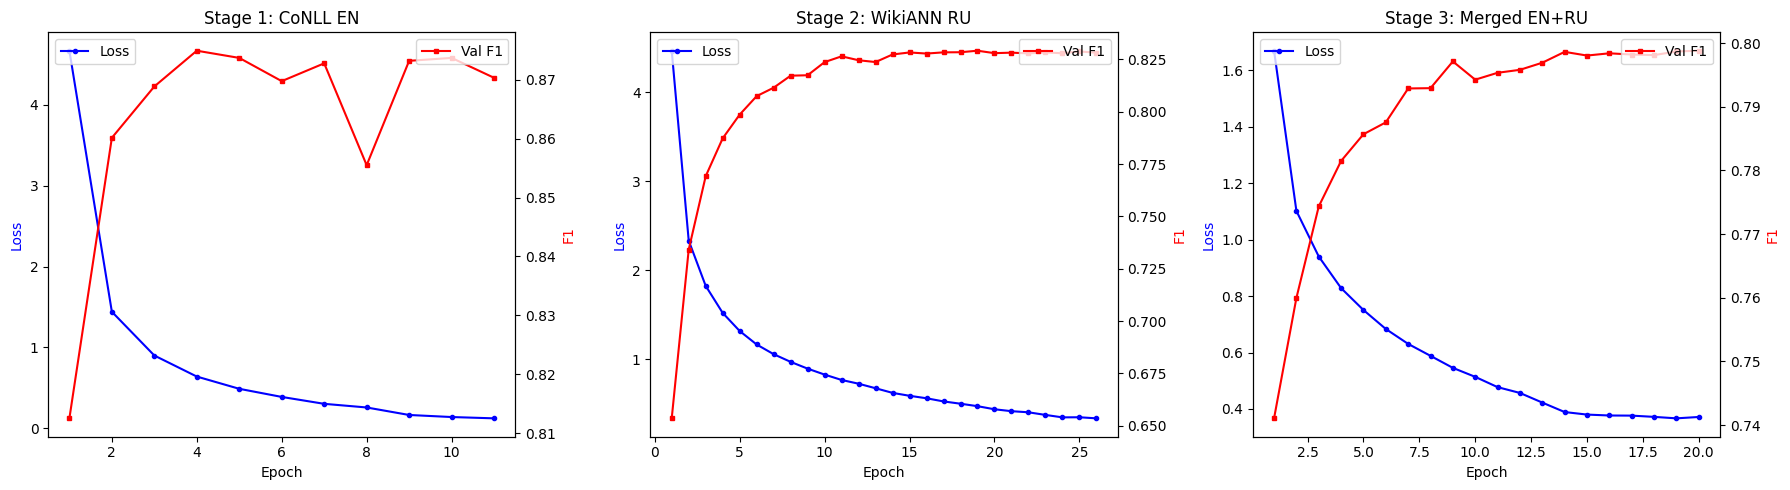

Saved to results/training_curves.png


In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, hist) in zip(axes, [
    ("Stage 1: CoNLL EN", en_hist),
    ("Stage 2: WikiANN RU", ru_hist),
    ("Stage 3: Merged EN+RU", merged_hist),
]):
    epochs = [h["epoch"] for h in hist]
    losses = [h["loss"] for h in hist]
    f1s = [h["val_f1"] for h in hist]

    ax2 = ax.twinx()
    ax.plot(epochs, losses, "b-o", markersize=3, label="Loss")
    ax2.plot(epochs, f1s, "r-s", markersize=3, label="Val F1")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss", color="b")
    ax2.set_ylabel("F1", color="r")
    ax.set_title(name)
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig("results/training_curves.png", dpi=150)
plt.show()
print("Saved to results/training_curves.png")

## 12. Quick Inference Test

In [16]:
from training.predict import NERPredictor

predictor = NERPredictor("configs/config.yaml", "checkpoints/merged_best.pt", "data/processed")

test_sentences = [
    "John Smith works at Google in New York",
    "Phone: +998881234567, Address: Andijan region",
    "Компания Яндекс расположена в Москве",
    "Contact us at office@example.com or visit our Tashkent branch",
    "Рабочие часы: 9:00 - 18:00, понедельник - пятница",
]

for sent in test_sentences:
    print(f"\nInput: {sent}")
    entities = predictor.extract_entities(sent)
    if entities:
        for e in entities:
            print(f"  [{e['type']:4s}] {e['text']}")
    else:
        print("  (no entities)")

2026-04-06 05:13:58,969 [INFO] Vocabulary loaded from data/processed/word_vocab.json: 26715 words
2026-04-06 05:13:58,971 [INFO] Character vocabulary loaded: 602 chars
2026-04-06 05:13:59,170 [INFO] Model loaded and ready



Input: John Smith works at Google in New York
  [PER ] John Smith
  [ORG ] Google in New York

Input: Phone: +998881234567, Address: Andijan region
  [LOC ] Andijan region

Input: Компания Яндекс расположена в Москве
  [LOC ] Москве

Input: Contact us at office@example.com or visit our Tashkent branch
  [LOC ] Tashkent branch

Input: Рабочие часы: 9:00 - 18:00, понедельник - пятница
  [ORG ] пятница


## 13. Save Final Model & Artifacts

In [17]:
final_dir = Path("final_model")
final_dir.mkdir(exist_ok=True)

torch.save(model.state_dict(), final_dir / "model_weights.pt")

import shutil
shutil.copy("data/processed/word_vocab.json", final_dir / "word_vocab.json")
shutil.copy("data/processed/char_vocab.json", final_dir / "char_vocab.json")
shutil.copy("data/processed/tag_map.json", final_dir / "tag_map.json")
shutil.copy("configs/config.yaml", final_dir / "config.yaml")

print("Final model artifacts saved to final_model/")
for f in sorted(final_dir.iterdir()):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  {f.name}: {size_mb:.1f} MB")

Final model artifacts saved to final_model/
  char_vocab.json: 0.0 MB
  config.yaml: 0.0 MB
  model_weights.pt: 41.6 MB
  tag_map.json: 0.0 MB
  word_vocab.json: 1.9 MB
